In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

## Load data 

In [3]:
dataPath = 'set-a-text/'
QRSSet  = {}
dataSet = {}

for i in range(1, 25):
    fileName = f'a{i:02d}.'
    try:
        QRSpositions = np.loadtxt(dataPath + fileName+'fqrs.txt', dtype=int)
        data = pd.read_csv(dataPath+fileName+'csv',skiprows=[0,1],names=['time','channel1','channel2','channel3','channel4'],)
        # print(f"File {fileName} loaded successfully.")
        dataSet[fileName] = data
        QRSSet[fileName] = QRSpositions
    except FileNotFoundError:
        print(f"File {fileName} not found.")
    except Exception as e:
        print(f"An error occurred while processing {fileName}: {e}")


In [3]:
dataSet['a01.']

,time,channel1,channel2,channel3,channel4
0,0.000,-3.3,-6.700,3.0,-3.5
1,0.001,-3.8,-6.700,3.0,-3.5
2,0.002,-4.4,-6.800,3.2,-3.5
3,0.003,-5.0,-6.900,3.2,-3.6
4,0.004,-5.6,-6.900,3.3,-3.7
...,...,...,...,...,...
59995,59.995,4.3,6.700,8.4,10.6
59996,59.996,4.2,6.600,8.0,10.1
59997,59.997,4.2,6.700,7.6,9.5
59998,59.998,4.2,7.000,7.0,8.8


In [4]:
from preprocessing.base import changeSamplingRate
from preprocessing.noiseRemoval import clean_data , baseline_wander_remover, Multi_Power_line_interference_canceller
from QRSDetector.base import multi_channel_QRS_enhancement , QRS_detector
from MECGDetector.base import mecg_cancellation
from evaluation.base import match_qrs_peaks, compute_evaluation_metrics
from MECGDetector.plotter import plot_mecg_removal_example
from utils.sanityCheck import plot_detected_reference_peaks


## Find the best Thresholds and Min distances

In [4]:
def run_detection_pipeline(ecg_data, reference_peaks, threshold, min_distance):
    # Step-by-step pipeline
    s1 = clean_data(ecg_data)
    s2 = baseline_wander_remover(s1, plot_results=False)
    s3 = Multi_Power_line_interference_canceller(s2)
    s4 = changeSamplingRate(s3, 1000, 2000)
    s4_pca = multi_channel_QRS_enhancement(s4, show_plot=False)
    qrs_peaks = QRS_detector(s4_pca, sampling_rate=2000, show_plot=False)
    s5, _ = mecg_cancellation(s4, qrs_peaks, fs=2000, N=10, correlation_threshold=0.7)
    s5_pca = multi_channel_QRS_enhancement(s5, show_plot=False)
    
    qrs_peaks_fetal = QRS_detector(
        s5_pca, sampling_rate=2000, 
        show_plot=False, 
        threshold=threshold, 
        min_distance=min_distance
    )
    
    tp, fp, fn = match_qrs_peaks(qrs_peaks_fetal, reference_peaks, fs=2000, tolerance_ms=75)
    return compute_evaluation_metrics(tp, fp, fn)


In [5]:
def grid_search_parameter_tuning(dataSet, QRSSet, thresholds, min_distances):
    results = []

    for threshold in thresholds:
        for min_dist in min_distances:
            all_metrics = []
            for file_key in dataSet.keys():
                metrics = run_detection_pipeline(
                    ecg_data=dataSet[file_key],
                    reference_peaks=QRSSet[file_key],
                    threshold=threshold,
                    min_distance=min_dist
                )
                metrics['file'] = file_key
                metrics['threshold'] = threshold
                metrics['min_distance'] = min_dist
                all_metrics.append(metrics)

            # Compute mean across all files
            df = pd.DataFrame(all_metrics)
            mean_metrics = df[['precision', 'recall', 'f1_score']].mean().to_dict()
            mean_metrics['threshold'] = threshold
            mean_metrics['min_distance'] = min_dist
            results.append(mean_metrics)

    return pd.DataFrame(results)


In [6]:
thresholds = [0.2, 0.25, 0.3, 0.35, 0.4]
min_distances = [0.2, 0.25, 0.3, 0.35]

result_df = grid_search_parameter_tuning(dataSet, QRSSet, thresholds, min_distances)


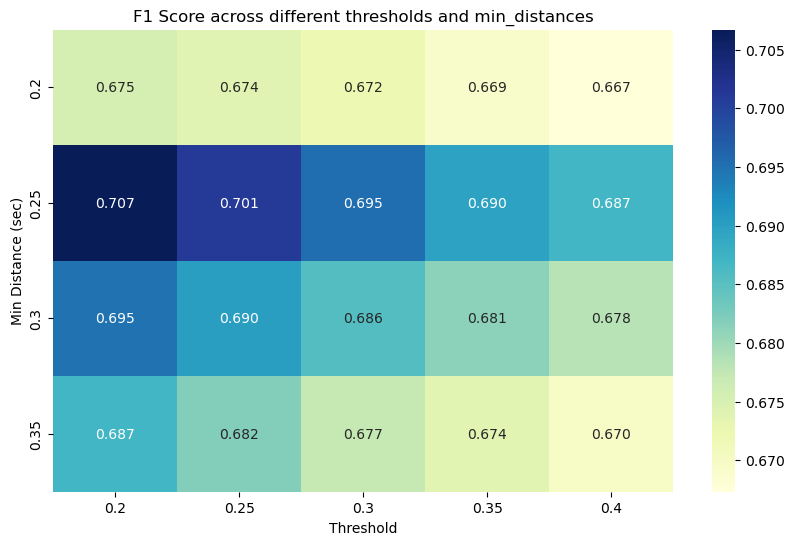

In [7]:
pivot_table = result_df.pivot(index="min_distance", columns="threshold", values="f1_score")

plt.figure(figsize=(10, 6))
sns.heatmap(pivot_table, annot=True, cmap="YlGnBu", fmt=".3f")
plt.title("F1 Score across different thresholds and min_distances")
plt.ylabel("Min Distance (sec)")
plt.xlabel("Threshold")
plt.show()


In [5]:
def run_dual_detection_pipeline(ecg_data, reference_peaks, 
threshold_maternal,min_distance_maternal,threshold_fetal,min_distance_fetal):
    # Step-by-step pipeline
    s1 = clean_data(ecg_data)
    s2 = baseline_wander_remover(s1, plot_results=False)
    s3 = Multi_Power_line_interference_canceller(s2)
    s4 = changeSamplingRate(s3, 1000, 2000)
    s4_pca = multi_channel_QRS_enhancement(s4, show_plot=False)
    qrs_peaks = QRS_detector(
        s4_pca, sampling_rate=2000, 
        show_plot=False, 
        threshold=threshold_maternal, 
        min_distance=min_distance_maternal
    )   
    s5, _ = mecg_cancellation(s4, qrs_peaks, fs=2000, N=10, correlation_threshold=0.7)
    s5_pca = multi_channel_QRS_enhancement(s5, show_plot=False)
    
    qrs_peaks_fetal = QRS_detector(
        s5_pca, sampling_rate=2000, 
        show_plot=False, 
        threshold=threshold_fetal, 
        min_distance=min_distance_fetal
    )
    
    tp, fp, fn = match_qrs_peaks(qrs_peaks_fetal, reference_peaks, fs=2000, tolerance_ms=75)
    return compute_evaluation_metrics(tp, fp, fn)


In [ ]:
def grid_search_dual_parameter_tuning(dataSet, QRSSet,
                                      maternal_thresholds, maternal_min_distances,
                                      fetal_thresholds, fetal_min_distances):
    results = []

    for thresh_m in maternal_thresholds:
        for dist_m in maternal_min_distances:
            for thresh_f in fetal_thresholds:
                for dist_f in fetal_min_distances:
                    all_metrics = []

                    for file_key in dataSet.keys():
                        metrics = run_dual_detection_pipeline(
                            ecg_data=dataSet[file_key],
                            reference_peaks=QRSSet[file_key],
                            threshold_maternal=thresh_m,
                            min_distance_maternal=dist_m,
                            threshold_fetal=thresh_f,
                            min_distance_fetal=dist_f
                        )
                        metrics['file'] = file_key
                        metrics['threshold_maternal'] = thresh_m
                        metrics['min_distance_maternal'] = dist_m
                        metrics['threshold_fetal'] = thresh_f
                        metrics['min_distance_fetal'] = dist_f
                        all_metrics.append(metrics)

                    df = pd.DataFrame(all_metrics)
                    mean_metrics = df[['precision', 'recall', 'f1_score']].mean().to_dict()
                    mean_metrics['threshold_maternal'] = thresh_m
                    mean_metrics['min_distance_maternal'] = dist_m
                    mean_metrics['threshold_fetal'] = thresh_f
                    mean_metrics['min_distance_fetal'] = dist_f
                    results.append(mean_metrics)

    return pd.DataFrame(results)

In [7]:
maternal_thresholds = [0.4, 0.5, 0.7, 0.8]
maternal_min_distances = [0.4, 0.5, 0.6, 0.7]
fetal_thresholds = [0.2, 0.3, 0.35]
fetal_min_distances = [0.2, 0.25, 0.3]

main_result_df = grid_search_dual_parameter_tuning(dataSet, QRSSet,  maternal_thresholds, maternal_min_distances,
                                      fetal_thresholds, fetal_min_distances)


In [8]:
main_result_df

,precision,recall,f1_score,threshold_maternal,min_distance_maternal,threshold_fetal,min_distance_fetal
0,0.638372,0.742583,0.683015,0.4,0.4,0.20,0.20
1,0.730763,0.701746,0.713819,0.4,0.4,0.20,0.25
2,0.733920,0.676176,0.700329,0.4,0.4,0.20,0.30
3,0.650065,0.723371,0.678990,0.4,0.4,0.30,0.20
4,0.728357,0.686588,0.702940,0.4,0.4,0.30,0.25
...,...,...,...,...,...,...,...
139,0.595018,0.499426,0.528933,0.8,0.7,0.30,0.25
140,0.598610,0.486797,0.524007,0.8,0.7,0.30,0.30
141,0.551565,0.506798,0.507764,0.8,0.7,0.35,0.20
142,0.588883,0.488859,0.519894,0.8,0.7,0.35,0.25


In [26]:
top4 = main_result_df.sort_values(by="f1_score", ascending=False,).head()
print(top4)

     precision    recall  f1_score  threshold_maternal  min_distance_maternal  \
37    0.730763  0.701746  0.713819                 0.5                    0.4   
1     0.730763  0.701746  0.713819                 0.4                    0.4   
109   0.730224  0.701851  0.713590                 0.8                    0.4   
73    0.730481  0.701486  0.713531                 0.7                    0.4   

     threshold_fetal  min_distance_fetal  
37               0.2                0.25  
1                0.2                0.25  
109              0.2                0.25  
73               0.2                0.25  


## Change the tolerance window to see the outcome

Mean Precision: 0.6874184223896279 Mean Recall: 0.6654997546399676 Mean F1 Score: 0.6746135986726652


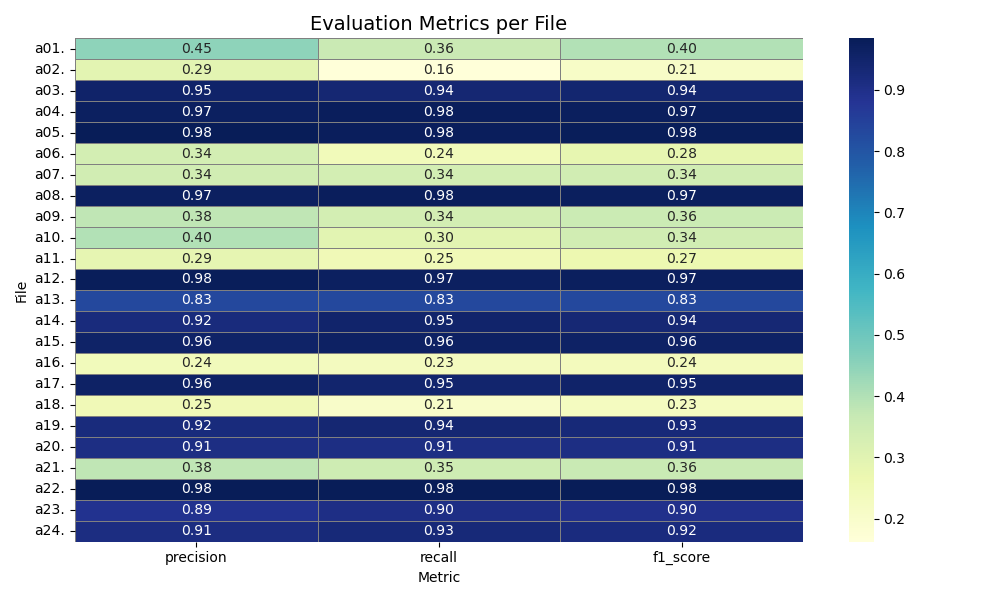

In [34]:
metrics ={}
for ecg in dataSet.keys():
    # Preprocess the ECG data
    data = dataSet[ecg]
    s1 = clean_data(data)
    s2 = baseline_wander_remover(s1,plot_results=False)
    s3 = Multi_Power_line_interference_canceller(s2)
    # Perform QRS detection
    s4 = changeSamplingRate(s3, 1000, 2000)
    s4_pca = multi_channel_QRS_enhancement(s4, show_plot=False)
    qrs_peaks = QRS_detector(s4_pca,sampling_rate=2000,threshold=0.5,min_distance=0.4, show_plot=False)
    # Perform MECG cancellation
    s5, _ = mecg_cancellation(s4,qrs_peaks,fs=2000,N=10,correlation_threshold=0.7)
    s5_pca = multi_channel_QRS_enhancement(s5,show_plot=False)
    # 
    qrs_peaks_fetal = QRS_detector(s5_pca,sampling_rate=2000, show_plot=False,threshold=0.2, min_distance=0.25)
    # Match QRS peaks
    reference_peaks = QRSSet[ecg]
    tp,fp,fn = match_qrs_peaks(qrs_peaks_fetal, reference_peaks,fs=2000,tolerance_ms=50)
    metrics[ecg] = compute_evaluation_metrics(tp=tp, fp=fp, fn=fn)

metrics_df = pd.DataFrame(metrics).T

mean_precision = metrics_df['precision'].mean()
mean_recall = metrics_df['recall'].mean()
mean_f1_score = metrics_df['f1_score'].mean()
print("Mean Precision:", mean_precision, "Mean Recall:", mean_recall, "Mean F1 Score:", mean_f1_score)

plt.figure(figsize=(10, 6))
sns.heatmap(metrics_df, annot=True, fmt=".2f", cmap="YlGnBu", linewidths=0.5, linecolor='gray')

# Customize the plot
plt.title("Evaluation Metrics per File", fontsize=14)
plt.xlabel("Metric")
plt.ylabel("File")

# Show the heatmap
plt.tight_layout()
plt.show()   


## Check a selected ECG file

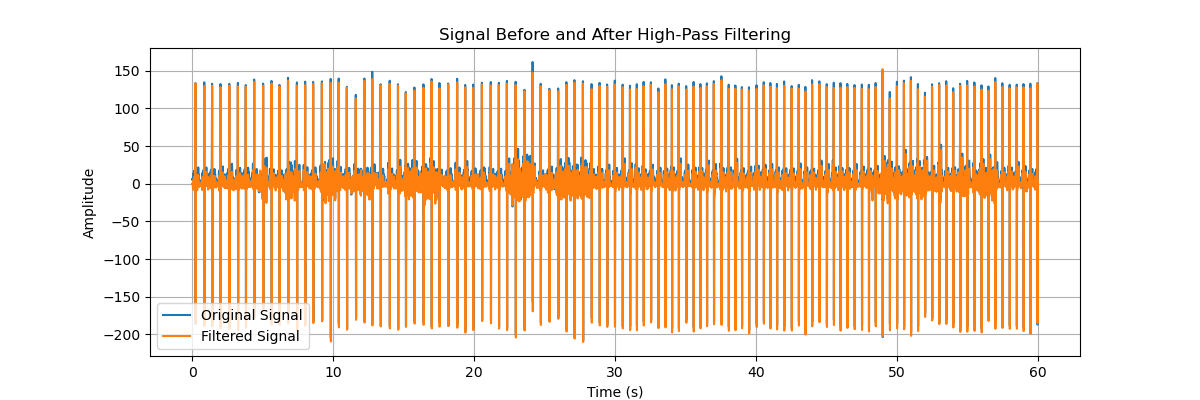

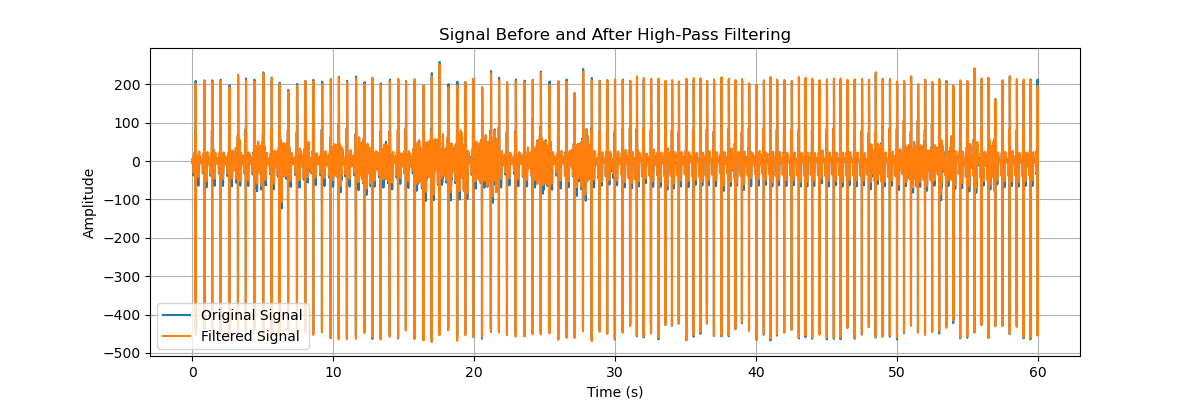

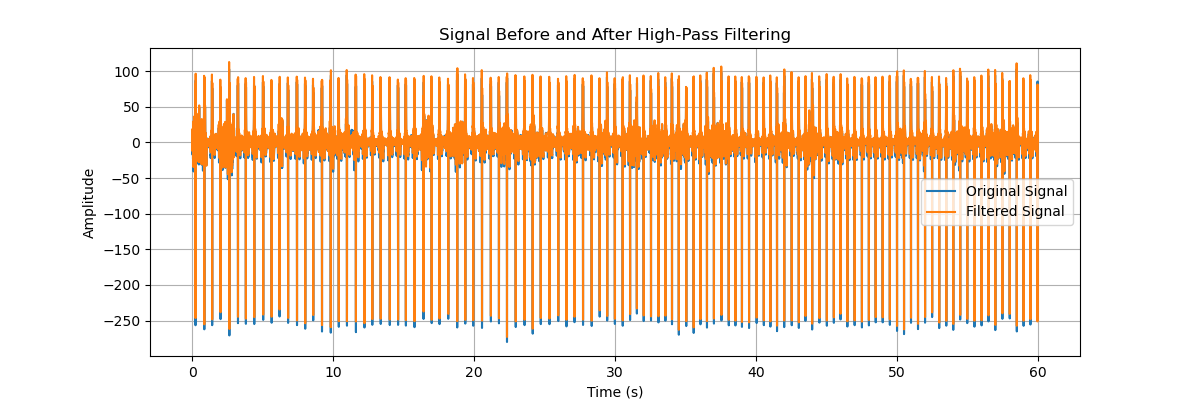

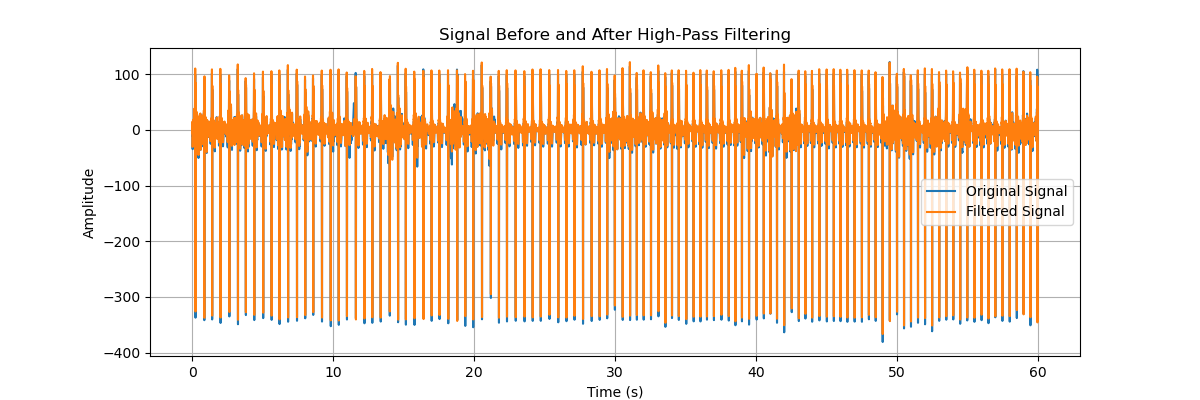

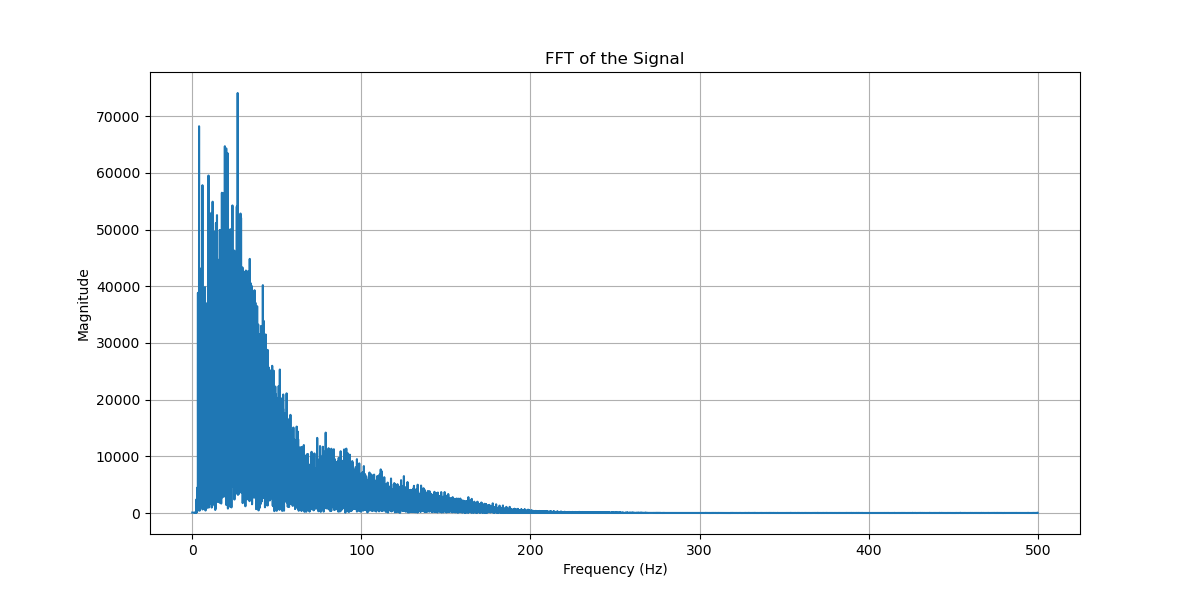

Frequency: 50.00 Hz, Magnitude: 11085.15
Frequency: 100.00 Hz, Magnitude: 5345.66
Frequency: 150.00 Hz, Magnitude: 1578.08
Frequency: 200.00 Hz, Magnitude: 122.20


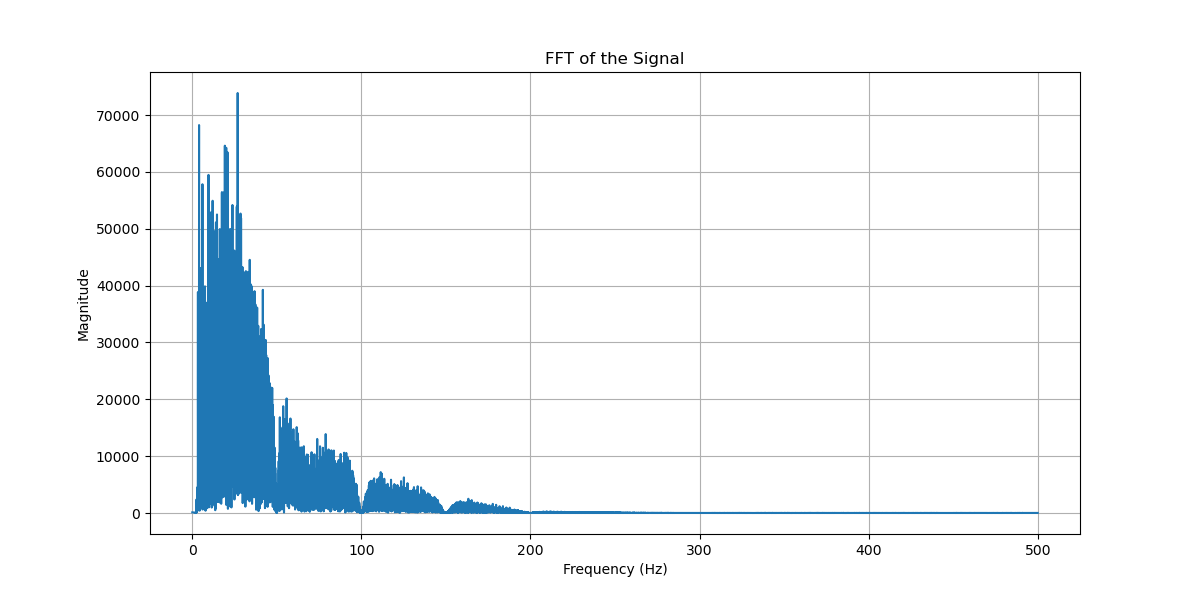

Frequency: 50.00 Hz, Magnitude: 136.12
Frequency: 100.00 Hz, Magnitude: 35.34
Frequency: 150.00 Hz, Magnitude: 6.12
Frequency: 200.00 Hz, Magnitude: 29.20


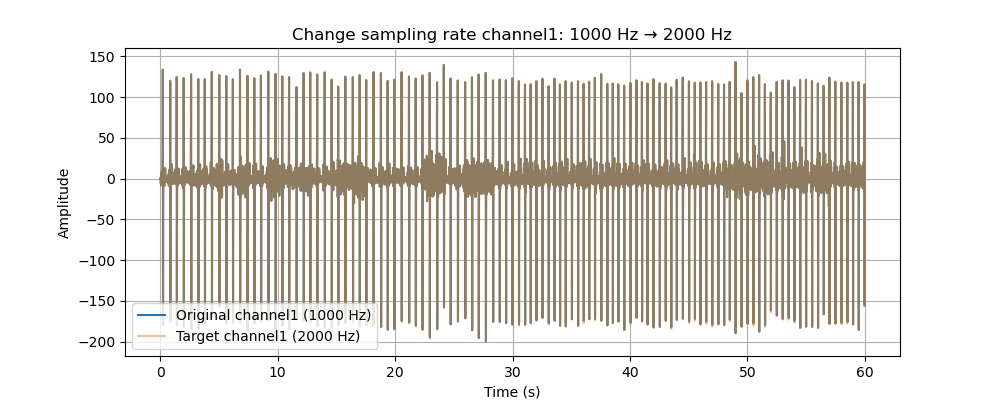

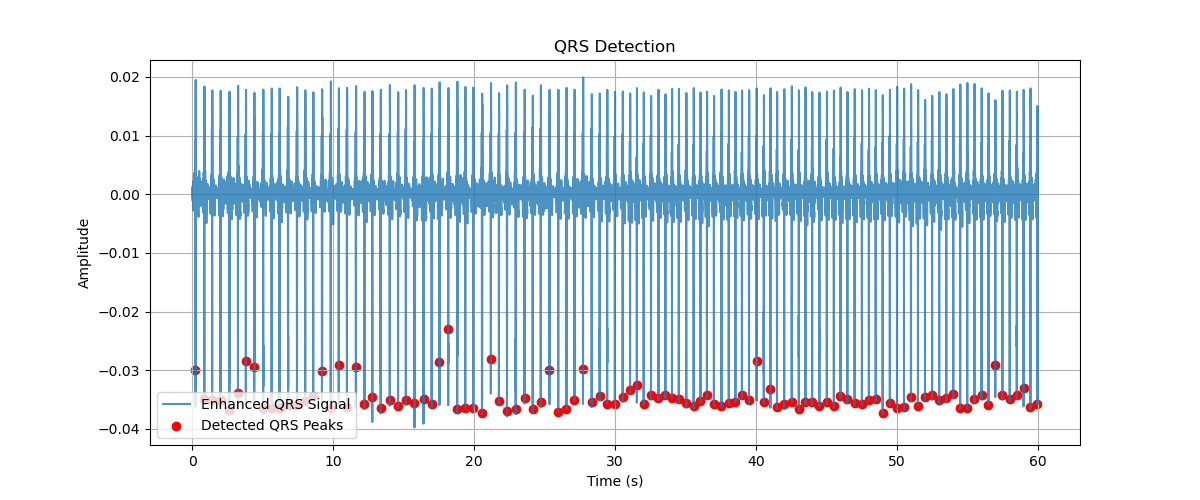

MHR:  111


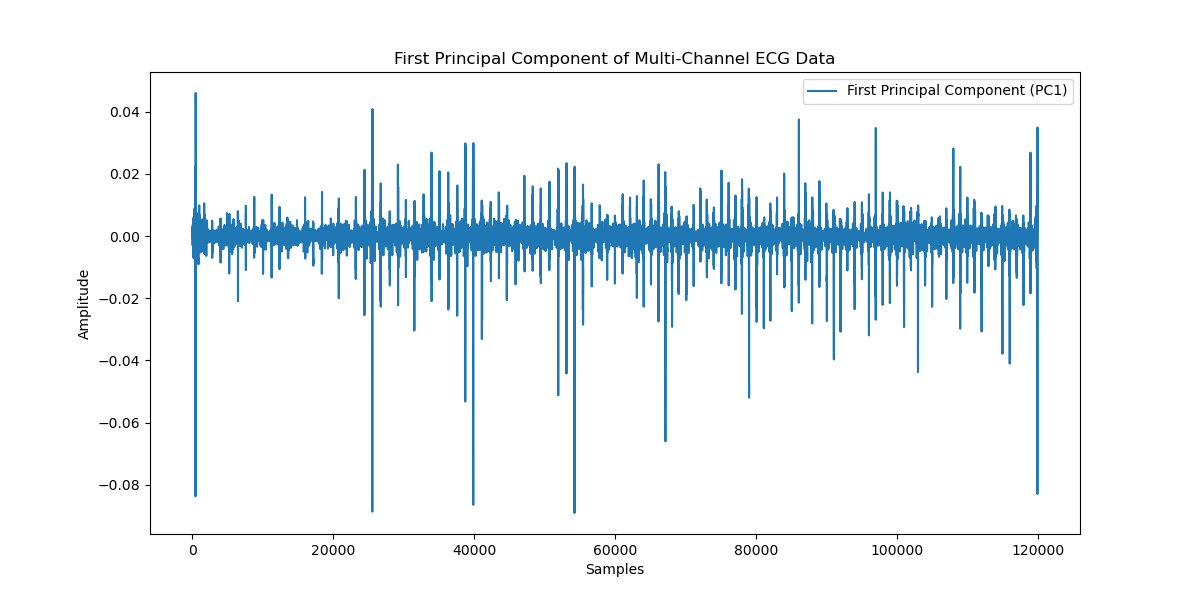

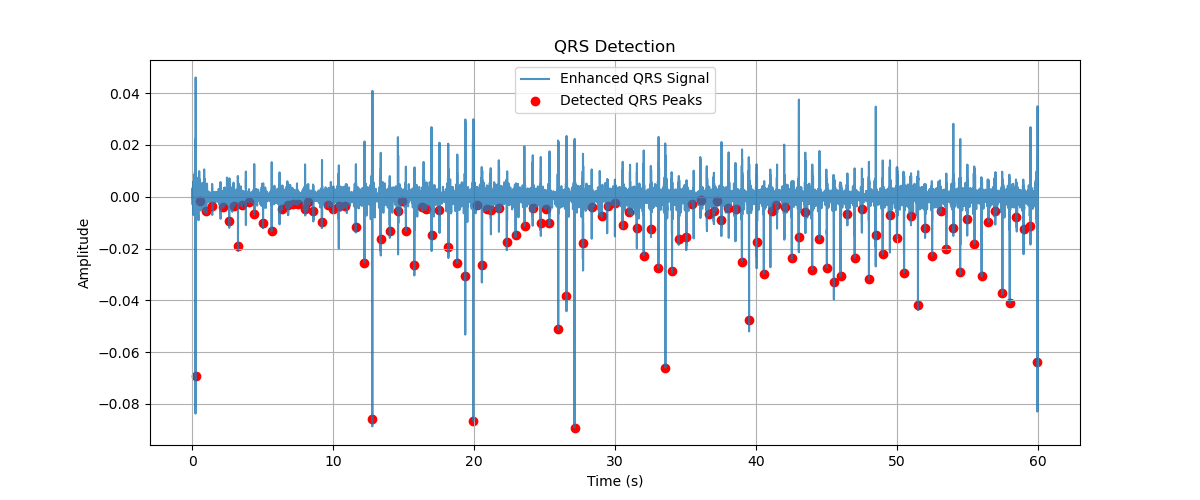

Reference Peaks:  150 Detected Peaks:  123


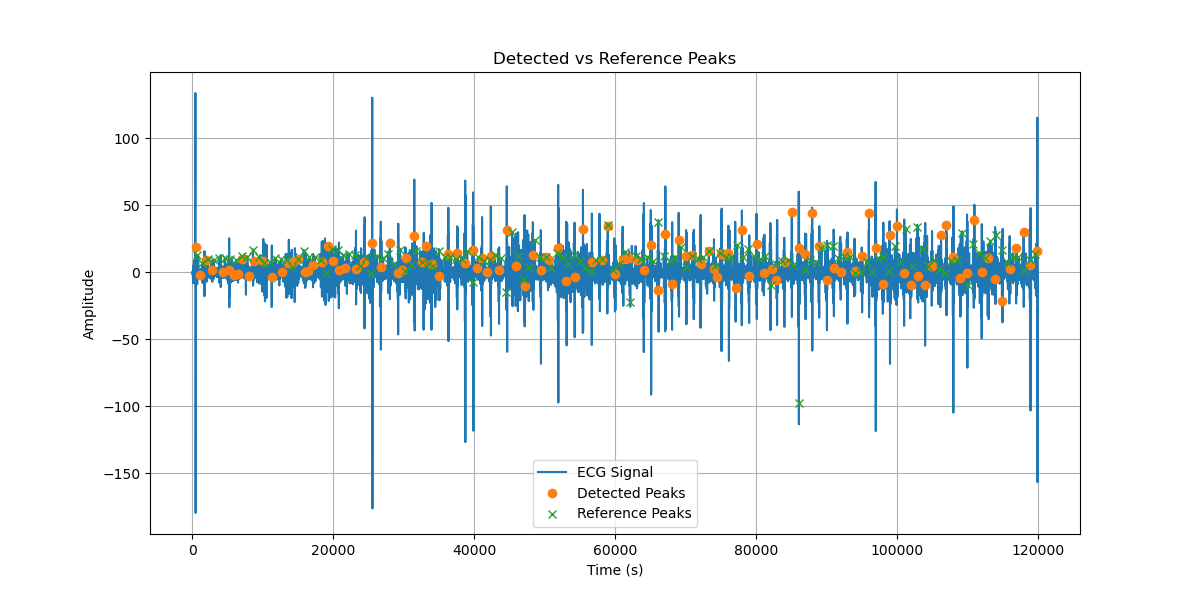

{'precision': 0.25203252032520324, 'recall': 0.20666666666666667, 'f1_score': 0.2271062271062271}


In [36]:
from utils.sanityCheck import check_noise
%matplotlib widget

# Preprocess the ECG data
data = dataSet['a18.']
s1 = clean_data(data)
s2 = baseline_wander_remover(s1,plot_results=True)
check_noise(s2.channel1)
s3 = Multi_Power_line_interference_canceller(s2)
check_noise(s3.channel1)
s4 = changeSamplingRate(s3, 1000, 2000,plot_result=True)
s4_pca = multi_channel_QRS_enhancement(s4, show_plot=False)
qrs_peaks = QRS_detector(s4_pca,sampling_rate=2000,threshold=0.5,min_distance=0.4, show_plot=True)
print('MHR: ',len(qrs_peaks))
# # Perform MECG cancellation
s5, _ = mecg_cancellation(s4,qrs_peaks,fs=2000,N=10,correlation_threshold=0.7)
# plot_mecg_removal_example(s4.channel1,s5.channel1,qrs_peaks,2000,i=13)
s5_pca = multi_channel_QRS_enhancement(s5,show_plot=True)
# # 
qrs_peaks_fetal = QRS_detector(s5_pca,sampling_rate=2000, show_plot=True,threshold=0.2, min_distance=0.25)
# # Match QRS peaks
reference_peaks = np.array(QRSSet['a18.'])
print('Reference Peaks: ',len(reference_peaks),'Detected Peaks: ',len(qrs_peaks_fetal))
# print(len(s5.channel1))
plot_detected_reference_peaks(s5.channel1,qrs_peaks_fetal,reference_peaks*2)
tp,fp,fn = match_qrs_peaks(qrs_peaks_fetal, reference_peaks,fs=2000,tolerance_ms=50)
metrics_values = compute_evaluation_metrics(tp=tp, fp=fp, fn=fn)
print(metrics_values)

In [ ]:
metrics ={}
for ecg in dataSet.keys():
    # Preprocess the ECG data
    data = dataSet[ecg]
    s1 = clean_data(data)
    s2 = baseline_wander_remover(s1,plot_results=False)
    check_noise(s2.channel1)
    s3 = Multi_Power_line_interference_canceller(s2)
    # Perform QRS detection
    s4 = changeSamplingRate(s3, 1000, 2000)
    s4_pca = multi_channel_QRS_enhancement(s4, show_plot=False)
    qrs_peaks = QRS_detector(s4_pca,sampling_rate=2000,threshold=0.5,min_distance=0.4, show_plot=False)
    # Perform MECG cancellation
    s5, _ = mecg_cancellation(s4,qrs_peaks,fs=2000,N=10,correlation_threshold=0.7)
    s5_pca = multi_channel_QRS_enhancement(s5,show_plot=False)
    # 
    qrs_peaks_fetal = QRS_detector(s5_pca,sampling_rate=2000, show_plot=False,threshold=0.2, min_distance=0.25)
    # Match QRS peaks
    reference_peaks = QRSSet[ecg]
    tp,fp,fn = match_qrs_peaks(qrs_peaks_fetal, reference_peaks,fs=2000,tolerance_ms=50)
    metrics[ecg] = compute_evaluation_metrics(tp=tp, fp=fp, fn=fn)

  
